In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

ret = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)["^GSPC"]
y = ret.values
T = len(y)
print(f"T = {T}")

T = 2515


The model. Non-centred parameterisation of the latent path — this is non-negotiable for SV, the centred version makes NUTS choke on the funnel.

In [9]:
import pytensor
import pytensor.tensor as pt
from pytensor import scan

with pm.Model() as sv_model:
    mu = pm.Normal("mu", mu=0.0, sigma=2.0)
    
    phi_raw = pm.Beta("phi_raw", alpha=20.0, beta=1.5)
    phi = pm.Deterministic("phi", 2.0 * phi_raw - 1.0)
    
    sigma_eta = pm.HalfNormal("sigma_eta", sigma=1.0)
    
    # Non-centred innovations
    eta = pm.Normal("eta", mu=0.0, sigma=1.0, shape=T)
    
    # Build h_t recursively using pytensor.scan
    def step(eta_t, h_prev, mu, phi, sigma_eta):
        return mu + phi * (h_prev - mu) + sigma_eta * eta_t
    
    # Stationary initial condition
    h0 = mu + sigma_eta / pt.sqrt(1.0 - phi**2) * eta[0]
    
    h_rest= pytensor.scan(
        fn=step,
        sequences=[eta[1:]],
        outputs_info=[h0],
        non_sequences=[mu, phi, sigma_eta],
    )
    
    h = pm.Deterministic("h", pt.concatenate([[h0], h_rest]))
    
    pm.Normal("r", mu=0.0, sigma=pt.exp(h / 2.0), observed=y)

/var/folders/x6/mjql4c2s4nsc6cnfqwqs46m40000gn/T/ipykernel_26730/1425418853.py:23: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  h_rest, _ = pytensor.scan(


Small Test:

In [10]:
with sv_model:
    idata_test = pm.sample(
        draws=300,
        tune=500,
        chains=2,
        target_accept=0.9,
        random_seed=42,
    )

print(az.summary(idata_test, var_names=["mu", "phi", "sigma_eta"]))
print(f"Divergences: {idata_test.sample_stats.diverging.sum().item()}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu, phi_raw, sigma_eta, eta]


Output()

Sampling 2 chains for 500 tune and 300 draw iterations (1_000 + 600 draws total) took 51 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


             mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu          -0.46   0.163    -0.73     -0.2       786       382  1.01   
phi        0.9636  0.0079     0.95     0.98       317       374  1.00   
sigma_eta   0.286   0.026     0.25     0.33       175       309  1.01   

          mcse_mean  mcse_sd  
mu           0.0058   0.0047  
phi         0.00043  0.00032  
sigma_eta    0.0019   0.0014  
Divergences: 0


Test Full Run:

In [13]:
with sv_model:
    idata = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.95,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, phi_raw, sigma_eta, eta]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2396 seconds.


ValueError: cannot write NetCDF files with format='NETCDF4' because none of the suitable backend libraries (netCDF4, h5netcdf) are installed

In [14]:
import pickle
with open("../data_and_results/sv_posterior.pkl", "wb") as f:
    pickle.dump(idata, f)

In [16]:
print(az.summary(idata, var_names=["mu", "phi", "sigma_eta"]))
print(f"Divergences: {idata.sample_stats.diverging.sum().item()}")

             mean      sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat  \
mu         -0.457   0.163    -0.71     -0.2      5165      4910  1.00   
phi        0.9633  0.0079     0.95     0.98      2360      3623  1.00   
sigma_eta   0.286  0.0269     0.24     0.33      1912      3220  1.00   

          mcse_mean  mcse_sd  
mu           0.0023   0.0018  
phi         0.00016  0.00012  
sigma_eta   0.00061  0.00044  
Divergences: 0


Diagnostic plots:

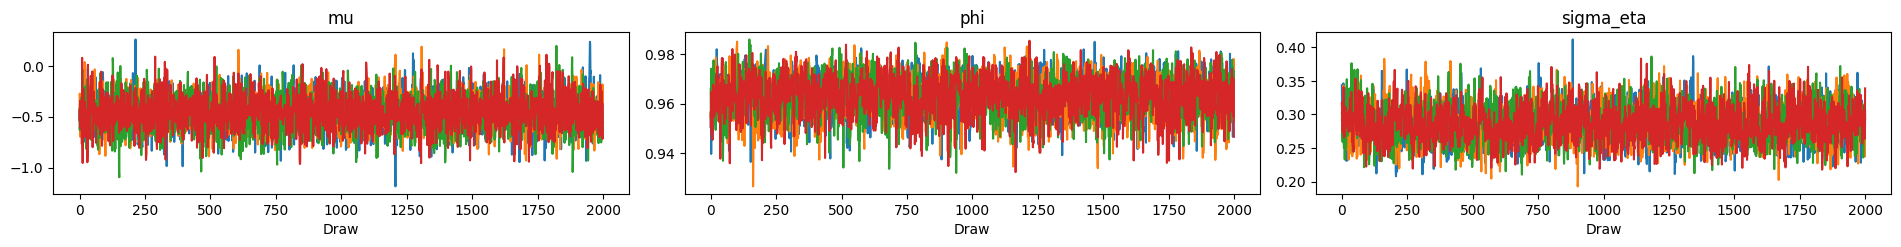

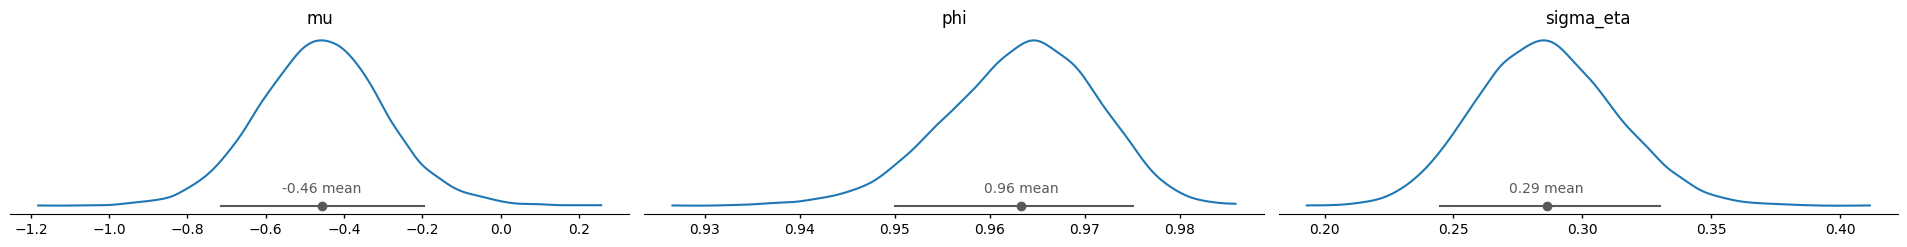

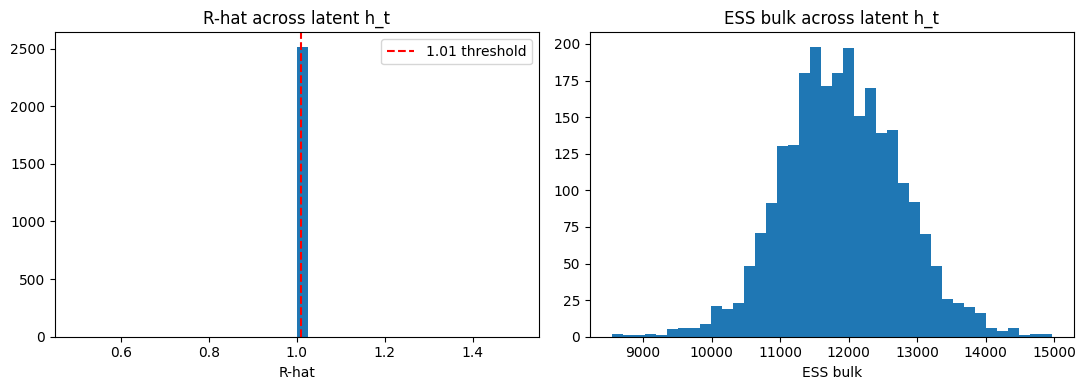

Max R-hat across h_t: 1.000
Min ESS bulk across h_t: 8541


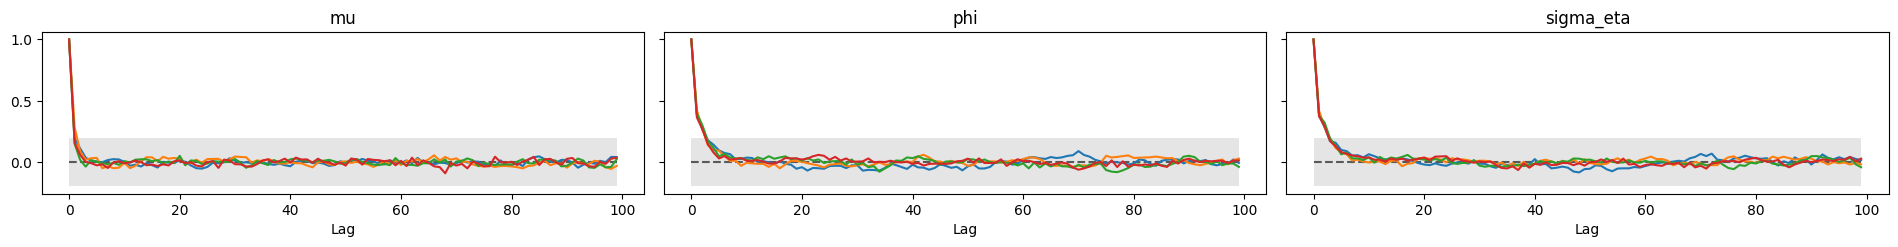

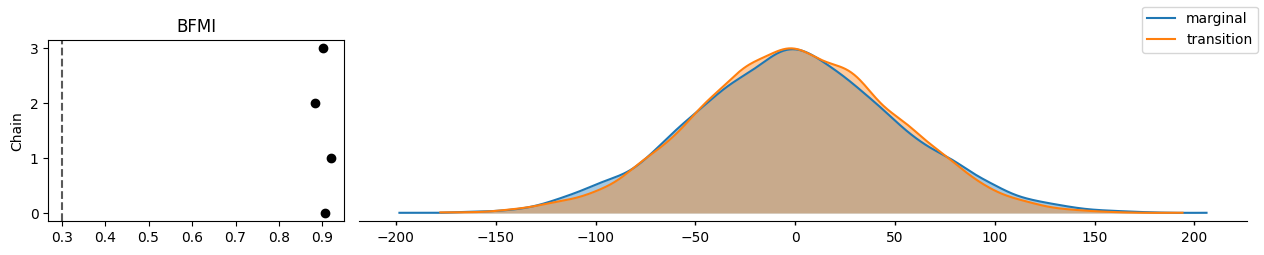

In [22]:
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Trace plot for the three scalar parameters ---
az.plot_trace(idata, var_names=["mu", "phi", "sigma_eta"])
plt.tight_layout()
plt.savefig("../figures/sv_trace.png", dpi=150)
plt.show()

# --- 2. Posterior densities ---
az.plot_dist(idata, var_names=["mu", "phi", "sigma_eta"])
plt.tight_layout()
plt.savefig("../figures/sv_posterior.png", dpi=150)
plt.show()

# --- 3. R-hat and ESS across the latent path ---
h_summary = az.summary(idata, var_names=["h"])
r_hat = pd.to_numeric(h_summary["r_hat"], errors="coerce")
ess_bulk = pd.to_numeric(h_summary["ess_bulk"], errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(r_hat.dropna(), bins=40)
axes[0].axvline(1.01, color="r", linestyle="--", label="1.01 threshold")
axes[0].set_title("R-hat across latent h_t")
axes[0].set_xlabel("R-hat")
axes[0].legend()
axes[1].hist(ess_bulk.dropna(), bins=40)
axes[1].set_title("ESS bulk across latent h_t")
axes[1].set_xlabel("ESS bulk")
plt.tight_layout()
plt.savefig("../figures/sv_latent_diagnostics.png", dpi=150)
plt.show()

print(f"Max R-hat across h_t: {r_hat.max():.3f}")
print(f"Min ESS bulk across h_t: {ess_bulk.min():.0f}")

# --- 4. Autocorrelation of the three parameters ---
az.plot_autocorr(idata, var_names=["mu", "phi", "sigma_eta"])
plt.tight_layout()
plt.savefig("../figures/sv_autocorr.png", dpi=150)
plt.show()

# --- 5. Energy plot (NUTS health check) ---
az.plot_energy(idata)
plt.tight_layout()
plt.savefig("../figures/sv_energy.png", dpi=150)
plt.show()